# 07b v2 — Torus 3D avec caméra alignée

Fix de la version précédente : on calcule automatiquement l'orientation caméra
pour qu'elle soit **perpendiculaire au plan moyen de l'anneau**, ce qui donne
la même perspective qu'Antoine (anneau vu de face, ellipses formant un tube).

## Méthode

1. PCA sur la trajectoire de référence → 3 vecteurs propres (axes principaux)
2. Le **3ème eigenvector** (plus petit eigenvalue) = **normale au plan de l'anneau**
3. Calcul des angles `elev` et `azim` pour orienter la caméra vers cette normale
4. Application via `ax.view_init(elev, azim)`

**Output** : `outputs/figures/fig4_torus_3d_full.png` (écrase la version précédente du 07b).

In [2]:
from resilience import paths, participants, config
from resilience.io import writer
from resilience.processing import detection, tde
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
%matplotlib inline

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 100, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

FIG_DIR = Path(paths.OUTPUTS_DIR) / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXAMPLE_P = '012WaCh'
COND_ORDER = ['silence', 'tempo_random', 'beatmove_adaptatif']
COND_LABELS = {'silence': 'Silence', 'tempo_random': 'Tempo random', 'beatmove_adaptatif': 'BeatMove'}

df_tde = pd.read_csv(Path(paths.OUTPUTS_DIR) / 'tables' / '04_tde_per_participant.csv')
tau_p = int(df_tde[df_tde['participant'] == EXAMPLE_P]['tau_p'].iloc[0])
m_p   = int(df_tde[df_tde['participant'] == EXAMPLE_P]['m_p'].iloc[0])

In [3]:
# Fonctions de la version précédente (recopiées)
def _fit_plane_poly11(x, y, z):
    A = np.column_stack([np.ones_like(x), x, y])
    coeffs, *_ = np.linalg.lstsq(A, z, rcond=None)
    return coeffs

def _rotation_to_align(a, b):
    a = a / np.linalg.norm(a); b = b / np.linalg.norm(b)
    c = np.cross(a, b)
    angle = np.arccos(np.clip(np.dot(a, b), -1, 1))
    axis = c / (np.linalg.norm(c) + 1e-12)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * K @ K

def _fourier_design_matrix(phases_deg, order):
    phi = np.deg2rad(phases_deg).reshape(-1, 1)
    k = np.arange(1, order + 1).reshape(1, -1)
    return np.hstack([np.ones((len(phases_deg), 1)),
                      np.sin(phi * k), np.cos(phi * k)])

def fourier_reference_trajectory(XR_3d, fourier_order=8):
    X, Y, Z = XR_3d[:, 0], XR_3d[:, 1], XR_3d[:, 2]
    Xo, Yo, Zo = np.nanmean(X), np.nanmean(Y), np.nanmean(Z)
    coeffs = _fit_plane_poly11(X, Y, Z)
    normal_vec = np.array([-coeffs[1], -coeffs[2], 1.0])
    R = _rotation_to_align(np.array([0., 0., 1.]), normal_vec)
    proj = np.column_stack([X - Xo, Y - Yo, Z - Zo]) @ R
    phase_pre = np.degrees(np.arctan2(proj[:, 1], proj[:, 0])) + 180
    idx_sorted = np.argsort(np.round(phase_pre))
    phase_sorted = np.round(phase_pre)[idx_sorted].astype(int) % 360
    Xs, Ys, Zs = X[idx_sorted], Y[idx_sorted], Z[idx_sorted]
    phase_fit = np.concatenate([phase_sorted, phase_sorted + 360]).astype(float)
    x_fit = np.concatenate([Xs, Xs])
    y_fit = np.concatenate([Ys, Ys])
    z_fit = np.concatenate([Zs, Zs])
    valid = np.isfinite(phase_fit) & np.isfinite(x_fit) & np.isfinite(y_fit) & np.isfinite(z_fit)
    phase_fit, x_fit, y_fit, z_fit = phase_fit[valid], x_fit[valid], y_fit[valid], z_fit[valid]
    phase_ref = np.arange(360)
    A_fit = _fourier_design_matrix(phase_fit, fourier_order)
    A_ref = _fourier_design_matrix(phase_ref, fourier_order)
    bx, *_ = np.linalg.lstsq(A_fit, x_fit, rcond=None)
    by, *_ = np.linalg.lstsq(A_fit, y_fit, rcond=None)
    bz, *_ = np.linalg.lstsq(A_fit, z_fit, rcond=None)
    ref_traj = np.column_stack([A_ref @ bx, A_ref @ by, A_ref @ bz])
    phase_data = np.column_stack([Xs, Ys, Zs, phase_sorted])
    return ref_traj, phase_data

def compute_local_frames(ref_traj):
    n = len(ref_traj)
    T, N, B = np.zeros((n, 3)), np.zeros((n, 3)), np.zeros((n, 3))
    def _norm(v):
        nrm = np.linalg.norm(v)
        return v / nrm if nrm > 1e-12 else v
    T[0] = _norm(ref_traj[1] - ref_traj[0])
    T[-1] = _norm(ref_traj[-1] - ref_traj[-2])
    for i in range(1, n - 1):
        T[i] = _norm(ref_traj[i + 1] - ref_traj[i - 1])
    N[0] = _norm(T[1] - T[0])
    N[-1] = _norm(T[-1] - T[-2])
    for i in range(1, n - 1):
        N[i] = _norm(T[i + 1] - T[i - 1])
    for i in range(n):
        B[i] = _norm(np.cross(T[i], N[i]))
    return T, N, B

def compute_local_std(ref_traj, phase_data):
    n = len(ref_traj)
    T, N, B = compute_local_frames(ref_traj)
    std_n = np.full(n, np.nan)
    std_b = np.full(n, np.nan)
    for k in range(n):
        mask = phase_data[:, 3] == k
        if mask.sum() < 2:
            continue
        vecs = phase_data[mask, :3] - ref_traj[k]
        std_n[k] = np.nanstd(vecs @ N[k], ddof=1)
        std_b[k] = np.nanstd(vecs @ B[k], ddof=1)
    return std_n, std_b, N, B

def generate_ellipses(ref_traj, std_n, std_b, N, B, scale=1.0, n_pts=50):
    theta = np.linspace(0, 2 * np.pi, n_pts)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    ellipses = np.zeros((len(ref_traj), n_pts, 3))
    for i in range(len(ref_traj)):
        a, b = scale * std_n[i], scale * std_b[i]
        if np.isnan(a) or np.isnan(b):
            ellipses[i] = np.nan
            continue
        e = np.outer(a * cos_t, N[i]) + np.outer(b * sin_t, B[i])
        ellipses[i] = e + ref_traj[i]
    return ellipses


def camera_perpendicular_to_ring(ref_traj):
    """
    Calcule (elev, azim) pour que la caméra soit perpendiculaire au plan de l'anneau.

    Méthode :
    1. PCA sur ref_traj → le 3ème eigenvector (smallest eigenvalue) = normale au plan
    2. Convertir cette normale (vecteur 3D) en angles sphériques (elev, azim)
    """
    centered = ref_traj - ref_traj.mean(axis=0)
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)  # croissant
    # Le plus petit eigenvalue → normale au plan
    normal = eigvecs[:, 0]
    # Convertir en angles sphériques matplotlib (elev = angle au-dessus du plan XY, azim = angle dans XY)
    elev = np.degrees(np.arcsin(normal[2]))
    azim = np.degrees(np.arctan2(normal[1], normal[0]))
    return elev, azim, normal

## Plot final avec caméra alignée

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_11068\779313284.py:12: RuntimeWarning: Mean of empty slice
  sac_xy = np.nanmean(dos_xy, axis=0)


silence: caméra naturelle elev=45.0° azim=16.6°  → ajustée elev=60.0°
tempo_random: caméra naturelle elev=45.2° azim=13.0°  → ajustée elev=60.2°
beatmove_adaptatif: caméra naturelle elev=44.5° azim=11.7°  → ajustée elev=59.5°


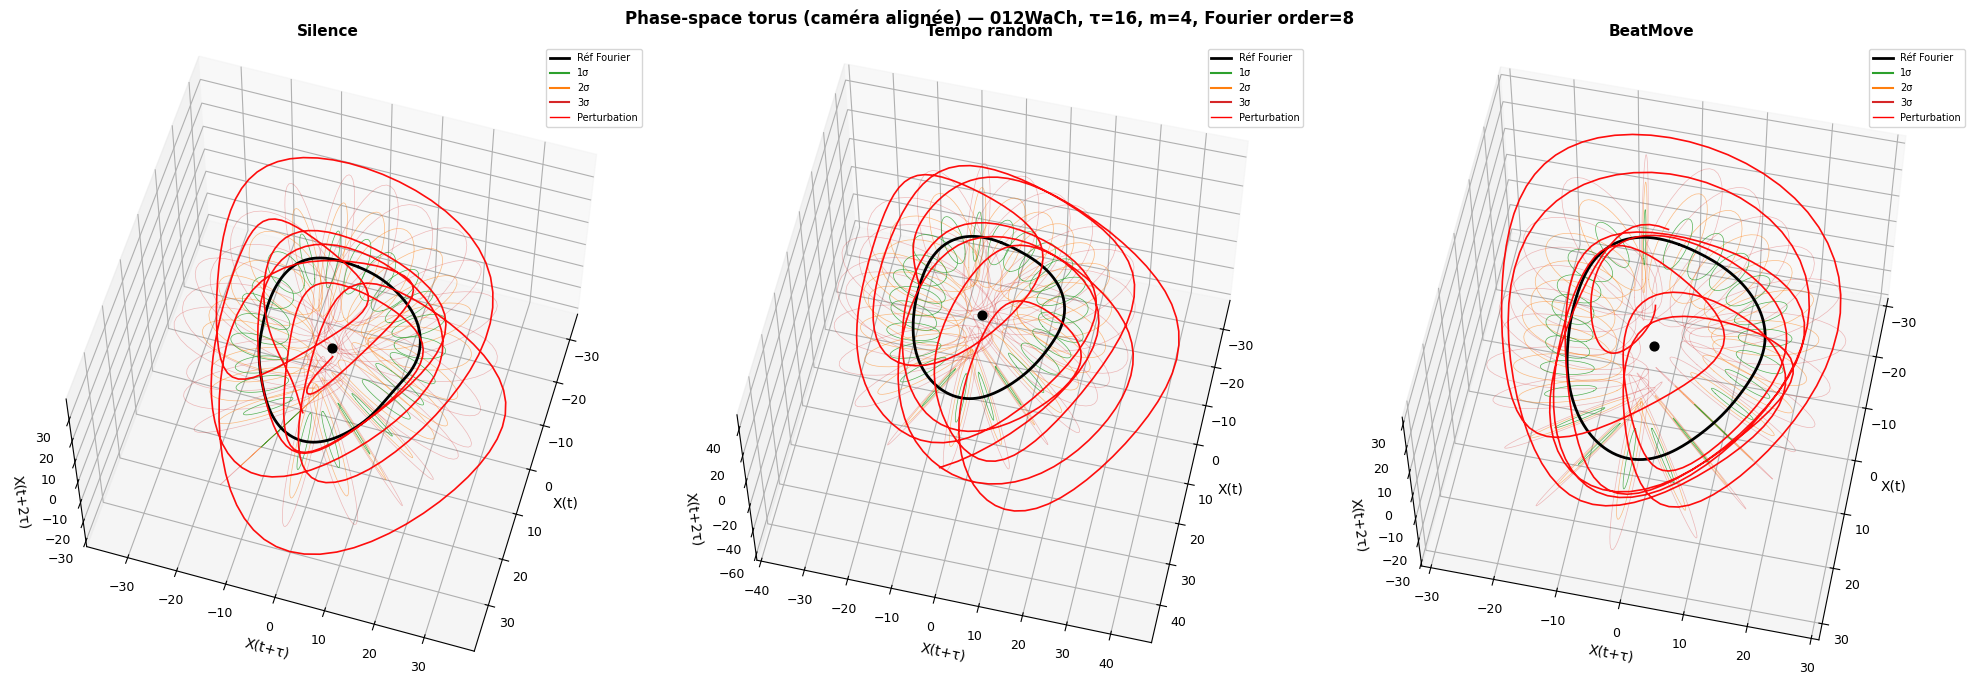


✅ Figure sauvegardée : C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\figures\fig4_torus_3d_full.png


In [4]:
SIGMA_COLORS = {1: '#2ca02c', 2: '#ff7f0e', 3: '#d62728'}
SIGMA_ALPHAS = {1: 0.8, 2: 0.5, 3: 0.3}

fig = plt.figure(figsize=(20, 7))

for i, cond in enumerate(COND_ORDER):
    d = writer.load_processed(EXAMPLE_P, cond)
    sig = d['signal_final'].astype(float)
    t = d['time_final'].astype(float)

    dos_xy = np.stack([d[f'raw_Dos{j:02d}'][:, :2] for j in range(1, 5)], axis=0)
    sac_xy = np.nanmean(dos_xy, axis=0)
    for ax_idx in range(2):
        col = sac_xy[:, ax_idx]
        if np.isnan(col).any():
            idx = np.arange(len(col))
            valid = ~np.isnan(col)
            if valid.sum() >= 2:
                col[~valid] = np.interp(idx[~valid], idx[valid], col[valid])
            sac_xy[:, ax_idx] = col
    det = detection.detect_sand_by_bbox(sac_xy)
    pert_entry, pert_exit = det['entry_t'], det['exit_t']

    XR = tde.phase_space_reconstruction(sig, tau=tau_p, dim=m_p)[:, :3]
    pad = (m_p - 1) * tau_p
    t_xr = t[pad:pad + XR.shape[0]]
    pert_mask = (t_xr >= pert_entry) & (t_xr <= pert_exit)
    XR_baseline = XR[~pert_mask]

    ref_traj, phase_data = fourier_reference_trajectory(XR_baseline, fourier_order=8)
    std_n, std_b, N, B = compute_local_std(ref_traj, phase_data)
    std_n_smooth = gaussian_filter1d(np.nan_to_num(std_n, nan=np.nanmean(std_n)), sigma=5)
    std_b_smooth = gaussian_filter1d(np.nan_to_num(std_b, nan=np.nanmean(std_b)), sigma=5)

    # Calcul angle caméra optimal (perpendiculaire au plan de l'anneau)
    elev, azim, normal = camera_perpendicular_to_ring(ref_traj)
    # On ne veut pas regarder PILE de face (anneau → cercle plat),
    # mais légèrement en biais pour voir le tube
    elev_adj = elev + 15  # 15° d'inclinaison pour voir le tube
    print(f"{cond}: caméra naturelle elev={elev:.1f}° azim={azim:.1f}°  → ajustée elev={elev_adj:.1f}°")

    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    # Ellipses 1σ, 2σ, 3σ (du plus grand au plus petit pour overlay)
    for sigma in [3, 2, 1]:
        ellipses = generate_ellipses(ref_traj, std_n_smooth, std_b_smooth,
                                       N, B, scale=sigma, n_pts=40)
        step = 15
        for k in range(0, len(ellipses), step):
            if not np.isnan(ellipses[k]).any():
                ax.plot(ellipses[k, :, 0], ellipses[k, :, 1], ellipses[k, :, 2],
                        color=SIGMA_COLORS[sigma], alpha=SIGMA_ALPHAS[sigma],
                        linewidth=0.5)

    # Trajectoire de référence Fourier
    ax.plot(ref_traj[:, 0], ref_traj[:, 1], ref_traj[:, 2],
            color='black', linewidth=2, label='Réf Fourier')

    # Trajectoire perturbation
    ax.plot(XR[pert_mask, 0], XR[pert_mask, 1], XR[pert_mask, 2],
            color='red', linewidth=1.2, alpha=0.95, label='Perturbation')

    # Centroïde
    ax.scatter(*XR_baseline.mean(axis=0), color='black', s=40, zorder=5)

    # FIX CAMERA
    ax.view_init(elev=elev_adj, azim=azim)

    ax.set_title(COND_LABELS[cond], fontweight='bold')
    ax.set_xlabel('X(t)')
    ax.set_ylabel('X(t+τ)')
    ax.set_zlabel('X(t+2τ)')

    legend_lines = [
        Line2D([0], [0], color='black', linewidth=2, label='Réf Fourier'),
        Line2D([0], [0], color=SIGMA_COLORS[1], label='1σ'),
        Line2D([0], [0], color=SIGMA_COLORS[2], label='2σ'),
        Line2D([0], [0], color=SIGMA_COLORS[3], label='3σ'),
        Line2D([0], [0], color='red', linewidth=1, label='Perturbation'),
    ]
    ax.legend(handles=legend_lines, fontsize=7, loc='upper right')

plt.suptitle(f'Phase-space torus (caméra alignée) — {EXAMPLE_P}, τ={tau_p}, m={m_p}, Fourier order=8',
              fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_torus_3d_full.png')
plt.show()

print(f"\n✅ Figure sauvegardée : {FIG_DIR / 'fig4_torus_3d_full.png'}")

## Notes

**Changement** : `ax.view_init(elev, azim)` calculé automatiquement depuis la PCA
de la trajectoire de référence. La normale au plan de l'anneau (= 3ème eigenvector)
est convertie en angles sphériques pour orienter la caméra perpendiculairement.

Un offset de `+15°` est appliqué pour ne pas être pile de face (anneau réduit à un cercle plat)
mais légèrement en biais pour voir le tube avec ses ellipses.